In [1]:
import os
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import numpy as np

import datetime

from numpy.random import choice

import doodl

import logging
logger = logging.getLogger()
logger.setLevel(logging.WARNING)
logging.debug("test")

from importlib import reload

/home/flann/.local/lib/python3.7/site-packages/pandas/core/ops/__init__.py:1115: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  result = method(y)


In [2]:
from doodl import Customer, JoeCustomer, SuperMarket

In [22]:
from matplotlib import cm

In [23]:
from imageio import imread, imwrite
from scipy.ndimage import rotate
from PIL import Image
import cv2

In [3]:
logger.setLevel(logging.WARNING)

### Load data

In [4]:
data = doodl.load_data()

In [5]:
aisles = doodl.get_aisles()
aisles

['fruit', 'spices', 'dairy', 'drinks', 'checkout']

In [6]:
df_location_by_time = doodl.get_customer_locations_by_time(data)

In [7]:
transition_matrix = doodl.get_trans_matrix(df_location_by_time)
transition_matrix

next aisle,fruit,spices,dairy,drinks,checkout
start aisle,,,,,
fruit,0.608945,0.049235,0.093196,0.053287,0.195336
spices,0.087202,0.427459,0.185247,0.156384,0.143708
dairy,0.047794,0.049250,0.748355,0.056155,0.098446
drinks,0.086873,0.085958,0.010770,0.603434,0.212965
checkout,0.000000,0.000000,0.000000,0.000000,1.000000


In [8]:
initial_choice_proba = doodl.get_first_aisle_pmf(df_location_by_time, day='all')
initial_choice_proba

fruit       0.377435
spices      0.181464
dairy       0.287576
drinks      0.153526
checkout    0.000000
Name: all days, dtype: float64

In [9]:
doodlmarkt_4 = SuperMarket(aisles=aisles, n_checkouts=4, exit_state="checkout", closing_time="09:10")

In [10]:
date = pd.to_datetime("2020-02-27")
%time records_df = doodlmarkt_4.day_in_the_life(date)

CPU times: user 171 ms, sys: 1.95 ms, total: 173 ms
Wall time: 153 ms


In [16]:
%time doodlmarkt_4.visualise()

CPU times: user 749 ms, sys: 5.66 ms, total: 755 ms
Wall time: 1.7 s


In [20]:
%time doodlmarkt_4.visualise_alt()

CPU times: user 1.88 s, sys: 34.4 ms, total: 1.91 s
Wall time: 2.86 s


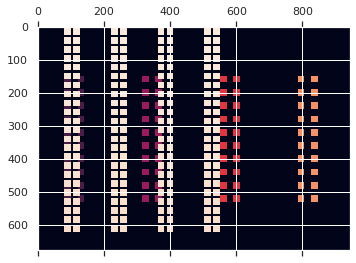

In [29]:
plt.matshow(doodlmarkt_4.locations_matrix[:,:,0])

In [12]:
raise Exception("stop")

Exception: stop

In [ ]:
doodlmarkt_no_queue = SuperMarket(aisles=aisles, checkout_rate=1, n_checkouts=4, exit_state="checkout")

In [ ]:
date = pd.to_datetime("2020-02-27")
%time records_df = doodlmarkt_no_queue.day_in_the_life(date)

In [ ]:
doodlmarkt_no_queue.visualise()

In [ ]:
doodlmarkt_3 = SuperMarket(aisles=aisles, n_checkouts=3, exit_state="checkout")

In [ ]:
date = pd.to_datetime("2020-02-27")
%time records_df = doodlmarkt_3.day_in_the_life(date)

In [ ]:
doodlmarkt_3.visualise()

In [ ]:
def get_customer_colour_df():
    """create data frame to match customer numbers to colours and location numbers for visualisation"""
    customer_colour_df = records_df.sort_values(by=['timestamp','location']).reset_index(drop=True)
    customer_colour_df = customer_colour_df.drop(columns="datetime")
    customer_colour_df['idx'] = customer_colour_df.index
    customer_colour_df = customer_colour_df.set_index(['timestamp', 'location'])
    customer_colour_df['idx'] = customer_colour_df['idx'] - customer_colour_df.reset_index().groupby(['timestamp', 'location'])['idx'].first()
    aisle_dict={k:v for v, k in enumerate(aisles)}
    customer_colour_df = customer_colour_df.reset_index(level=1)
    customer_colour_df['idx'] = customer_colour_df['idx'] + customer_colour_df['location'].apply(aisle_dict.get) * 1000
    customer_colour_df['colour'] = customer_colour_df['customer_no'].apply(cmap).apply(lambda x: x[:3])
    return customer_colour_df.reset_index().set_index(['timestamp', 'location'])

In [ ]:
def get_locations_matrix():
    """Create the matrix containing the location numbers for the visualisation"""
    icon_locations = np.ones_like(doodlmarkt_4.img) * doodlmarkt_4.no_value
    for i,a in enumerate(doodlmarkt_4.aisles):
        if a==doodlmarkt_4.exit_state:
            for loc in range(doodlmarkt_4.nrow_checkouts * doodlmarkt_4.ncol_checkouts):
                row = loc // doodlmarkt_4.ncol_checkouts
                col = loc % doodlmarkt_4.ncol_checkouts
                yul = doodlmarkt_4.checkout_bottom - (doodlmarkt_4.square_side + doodlmarkt_4.checkout_icon_divide) * row
                xul = (doodlmarkt_4.offset + int(doodlmarkt_4.checkout_section_width/4)
                                    * (col//doodlmarkt_4.cols_per_checkout)
                                    + (doodlmarkt_4.square_side + doodlmarkt_4.checkout_icon_divide) * col)
                icon_locations[yul:yul+doodlmarkt_4.square_side, xul:xul+doodlmarkt_4.square_side] = i*1000 + loc
            
        else:
            for loc in range(doodlmarkt_4.nrow_aisles * doodlmarkt_4.ncol_aisles):
                row = loc // doodlmarkt_4.ncol_aisles
                col = loc % doodlmarkt_4.ncol_aisles
                yul = doodlmarkt_4.aisles_top + (doodlmarkt_4.square_side + doodlmarkt_4.aisle_icon_divide) * row
                xul = doodlmarkt_4.offset + int(doodlmarkt_4.img_width/4) * i + (doodlmarkt_4.square_side + doodlmarkt_4.aisle_icon_divide) * col

                icon_locations[yul:yul+doodlmarkt_4.square_side, xul:xul+doodlmarkt_4.square_side] = i*1000 + loc

    return icon_locations

In [ ]:
customer_colour_df = get_customer_colour_df()

In [ ]:

cmap = cm.get_cmap('hsv', 1000)

In [ ]:
customers = customer_colour_df.loc[time]
customer_count = customers.count()#.reset_index()#.groupby(['location', 'customer_no']).all()#.unstack(-1)

In [ ]:
customer_count = customers.reset_index().groupby(['location'])['customer_no'].count()
customer_count

In [ ]:
i = 1

In [ ]:
customer_count[customer_count.index!="checkout"]#.sum()


In [ ]:
%%timeit
s =  customers.set_index('idx')['colour'].apply(lambda x: x[0])
r_matrix = np.ones_like(icon_locations[:,:,0]) * doodlmarkt_4.no_value
r_matrix = np.where(np.isin(r_matrix, s.index), s.get, r_matrix)
r_matrix

In [ ]:
%%timeit
s =  customers.set_index('idx')['colour'].apply(lambda x: x[0])
r_matrix = np.ones_like(icon_locations[:,:,0]) * doodlmarkt_4.no_value
for i, r in s.iteritems():
    r_matrix = np.where(r_matrix==i, r, r_matrix)
# icon_locations[:,:,0](s)
r_matrix

In [ ]:
%%timeit
icons_layer = np.ones_like(icon_locations, dtype=float) * doodlmarkt_4.no_value
for i, col in enumerate(['r','g','b']):
    loc_to_channel_level =  customers.set_index('idx')['colour'].apply(lambda x: x[i])
    for loc, level in loc_to_channel_level.iteritems():
        icons_layer[:,:,i] = np.where(icon_locations[:,:,i]==loc, level, icons_layer[:,:,i])


#### To do:

* use binomial dist to get new customers
* investigate old customer dist
* colour customers in visualisation by minute
* keep track of customers in visualisation
* fix checkout visualisation - propagate horizontally first